# AP 155 Lab Exercise
---
## Exercise 6: Eigenfunctions and Eigenvalues of a Hamiltonian

_Instructions_: 
- **Problem 1 Report figure:** First 5 wavefunctions of the harmonic oscillator.
- **Problem 2 Report figure:** Energy analysis and plotting of probability density.
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Pasion, Kyla Zarina
- _Student No._: 2024-09224
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

<!-- ### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.
-->

### Report discussion

**Problem 1: Hamiltonian Matrix and its Eigs**

![The First Five Eigenstates of the Quantum Harmonic Oscillator](./Figures/e6_figure1.png)

*Figure 1: The First Five Eigenstates of the Quantum Harmonic Oscillator*

The Hamiltonian matrix was constructed by discretizing the kinetic energy operator using the central finite-difference method and representing the harmonic potential as a diagonal matrix. The resulting matrix eigenvalue problem was solved using `np.linalg.eigh` over the spatial grid. Numerical diagonalization yielded the first five eigenvalues, $E_0 = 0.40$, $E_1 = 1.20$, $E_2 = 2.00$, $E_3 = 2.79$, and $E_4 = 3.59$. These values show close agreement with the theoretical expression $E_n = \hbar\omega(n + \frac{1}{2})$, which gives $0.4$, $1.2$, $2.0$, $2.8$, and $3.6$ for $\omega = 0.8$ and $\hbar = 1$.

The offset wavefunctions, $f_n = \psi_n + E_n$, exhibit the expected behavior of quantum harmonic oscillator eigenstates. Each $n$-th eigenfunction contains exactly $n$ spatial nodes within the parabolic potential. The wavefunctions also extend beyond the classical turning points before decaying exponentially in the classically forbidden regions, demonstrating quantum tunneling. These results show that the central finite-difference approximation of the kinetic energy operator successfully reproduces the expected energy spectrum and spatial behavior of the quantum harmonic oscillator.

**Problem 2: Harmonic Oscillator in an Electric Field**

![Comparison of Numerical and Theoretical Energy Eigenvalues for 50 States](./Figures/e6_figure2.png)

*Figure 2: Comparison of Numerical and Theoretical Energy Eigenvalues for 50 States*

![Potential and Ground-State Probability Density](./Figures/e6_figure3.png)

*Figure 3: Potential and Ground-State Probability Density*

As shown in Figure 2, the numerical eigenenergies calculated using the matrix method closely match the theoretical values for the lower energy states. At higher quantum numbers $n$, the numerical results increasingly diverge from the theoretical predictions, with the numerical energies becoming larger. This deviation occurs because higher-energy wavefunctions have wider spatial distributions and more rapid oscillations, causing them to increasingly interact with the artificial boundaries of the finite computational grid at $x = \pm 10$. These hard boundaries effectively confine the wavefunctions, causing their energies to be overestimated relative to the theoretical values.

Furthermore, Figure 3 demonstrates the expected physical behavior of the ground state under a uniform electric field. The addition of the linear term shifts the minimum of the harmonic potential to the left and lowers its minimum energy. The ground-state probability density $\lvert\psi_0(x)\rvert^2$ retains its standard Gaussian shape and is centered at the newly displaced minimum of the effective potential $V(x)$. The numerical ground-state energy of $E_0 = -0.38$ also closely agrees with the theoretically shifted energy baseline.

### Other comments
- N/A


---
## Section 2: Code

### Problem 1: Hamiltonian Matrix and its Eigs

The time-independent Schrödinger equation is:

$$
\left[-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}+\hat{V}(x)\right]\psi(x)=\left[\hat{T} + \hat{V} \right]\psi=E_n\psi(x).
$$

In quantum mechanics, we can represent operators (e.g. $\hat{T}$ and $\hat{V}$) as matrices, while the quantum state (in this case, $\psi$) is written as an $N \times 1$ vector

$$ \psi = 
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix}
$$

where $\psi_i$ represents the value of the wave function at $x_i$. Now, we know that $\left[\hat{V}(x)\psi(x)\right]|_{x_i} \equiv V(x_i)\psi(x_i) = V_i \psi_i$. We can write this statement as:

$$\hat{V}
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = 
\begin{bmatrix}
V_1\psi_1 \\
V_2\psi_2 \\
\vdots \\
V_i\psi_i \\
\vdots \\
V_N\psi_N
\end{bmatrix}
$$

This relation only holds true when $\hat{V}$ is an $N \times N$ square diagonal matrix of the form:

$$
\boxed{\hat{V}=
\begin{pmatrix}
V_1 & 0 & 0 & \cdots & 0 & 0 & 0 \\
0 & V_2 & 0 & \cdots & 0 & 0 & 0 \\
0 & 0 & V_3 & \cdots & 0 & 0 & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
0 & 0 & 0 & \cdots & V_i & 0 & 0 \\
0 & 0 & 0 & \cdots & 0 & \ddots & 0 \\
0 & 0 & 0 & \cdots & 0 & 0 & V_N
\end{pmatrix}
}
$$

where $V_i$ denotes the potential's value at $x_i$. This is then what we call the "matrix representation" of the operator $\hat{V}$! At least, in the position basis -- more info on 142 or 241 :)

**(a)** On a piece of paper, find the matrix representation of the kinetic energy operator $\hat{T} \equiv \cfrac{-\hbar^2}{2m}\cfrac{\partial^2}{\partial x^2}$. Use the fact that 

$$
f''(x_i)=
\frac{f(x_{i+1}) - 2f(x_i) + f(x_{i-1})}{(\Delta x)^2}
$$

The first step of this problem would be to solve
$$
\cfrac{\partial^2}{\partial x^2}\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = \ ?
$$

and then to find a matrix representation for $\cfrac{\partial^2}{\partial x^2}$ operator. Your result should look like a square diagonal matrix

$$
\boxed{\hat{T}=
-\frac{\hbar^2}{2m(\Delta x)^2}
\begin{pmatrix}
-2 & 1 & 0 & 0 & 0 & \cdots & 0 \\
1 & -2 & 1 & 0 & 0 & \cdots & 0 \\
0 & 1 & -2 & 1 & 0 & \cdots & 0 \\
0 & 0 & 1 & -2 & 1 & \ddots & \vdots \\
0 & 0 & 0 & 1 & -2 & \ddots & 0 \\
\vdots & \vdots & \vdots & \ddots & \ddots & \ddots & 1 \\
0 & 0 & 0 & \cdots & 0 & 1 & -2
\end{pmatrix}
}
$$

**(b)** Write a function that outputs the Hamiltonian ($\hat{T} + \hat{V})$ matrix `hamiltonian(x_pos, potential_array, mass)` where `x_pos` and `potential_array` are both $N \times 1$ arrays (vectors), while `mass` is a scalar. The former represents position coordinates while the latter represents potential values at these coordinates. You might want to use `np.eye()`.

**(c)** Test your `hamiltonian()` function for the case where $V(x) = \cfrac{1}{2}m\omega^2x^2$. Obtain the first $N=5$ eigenfunctions of your Hamiltonian using `np.linalg.eigh()`, and obtain their corresponding eigenvalues. Plot the eigenfunctions, then offset each to its corresponding eigenvalue. In essence, you will plot $f_n$ where

$$
f_n = \psi_n + E_n
$$

Lastly, overlay the harmonic potential $V$ on the plot itself. Assume that $m=\hbar=1$ while $\omega=0.8$. 

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def hamiltonian(x_pos, potential_array, mass):

    N = len(x_pos)
    dx = x_pos[1] - x_pos[0]

    # Construct second derivative matrix
    diag = -2 * np.eye(N)
    off_diag = np.eye(N, k=-1) + np.eye(N, k=1)

    D = (diag + off_diag) / (dx**2)

    # Construct kinetic energy matrix
    T = -(hbar**2 / (2 * mass)) * D

    # Construct potential energy matrix
    V = np.diag(potential_array)

    # Hamiltonian
    H = T + V

    return H

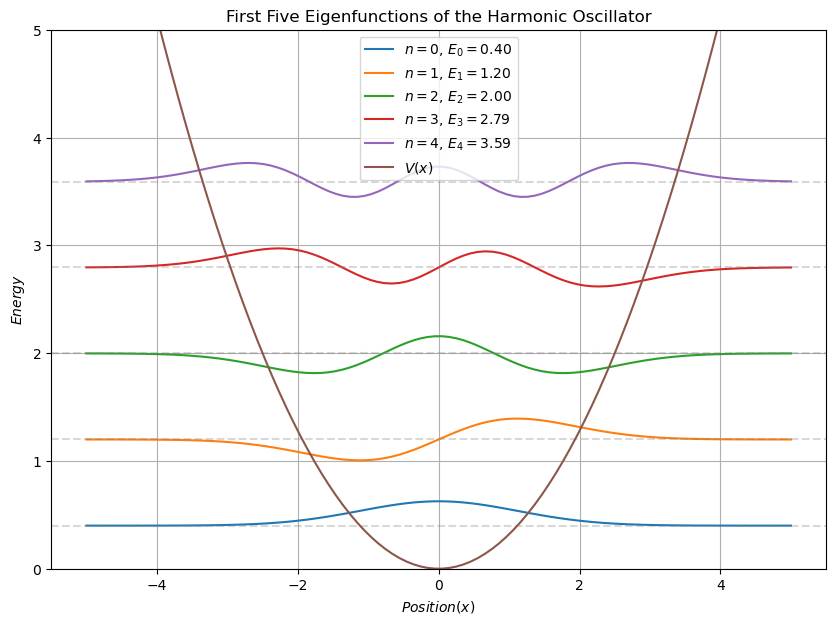

In [9]:
# Parameters
m = 1
hbar = 1
w = 0.8
N_points = 100
x = np.linspace(-5, 5, N_points)
dx = x[1] - x[0]


# Harmonic oscillator potential
Vx = 0.5 * m * (w**2) * (x**2)

H = hamiltonian(x, Vx, m)

# Obtain eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(H)

plt.figure(figsize=(10, 7))

for n in range(5):
    E_n = eigenvalues[n]

    # Normalize eigenfunction
    psi_n = eigenvectors[:, n]
    
    # Offset eigenfunction by its energy
    f_n = (psi_n) + E_n

    plt.plot(x, f_n, label=f"$n={n}$, $E_{n}={E_n:.2f}$")
    plt.axhline(E_n, color='gray', linestyle='--', alpha=0.3)

# Plot harmonic oscillator potential
plt.plot(x, Vx, label="$V(x)$")

# Set plot limits
plt.ylim(0, 5)

plt.xlabel("$Position (x)$")
plt.ylabel("$Energy$")
plt.title("First Five Eigenfunctions of the Harmonic Oscillator")
plt.legend()
plt.grid()
plt.savefig('Figures/e6_figure1')
plt.show()

#### Problem 1 code summary

This code constructs the Hamiltonian matrix for a one-dimensional harmonic oscillator by combining the finite-difference kinetic energy matrix with the diagonal potential energy matrix. The Hamiltonian is then diagonalized using `np.linalg.eigh` to obtain the eigenvalues and eigenvectors, which are used to plot the first five energy eigenstates together with the harmonic oscillator potential.

---

### Problem 2: Harmonic Oscillator in an Electric Field

The effective potential of an oscillator immersed in a uniform electric field is

$$
V(x) = \cfrac{1}{2}m\omega^2x^2 + qEx
$$

where $q$ is the particle's charge, and $E$ is the strength of the applied uniform electric field.

**(a)** Assume that the particle is an electron and it is immersed in a field of strength $E=q^{-1}$. Plot 100 eigenenergies of the resulting Hamiltonian, and compare it with the theoretical value of

$$
E_n = \hbar \omega \left(n+\cfrac{1}{2} \right) - \cfrac{q^2 E^2}{2m \omega^2}
$$

Did you get the expected result? Why or why not?

**(b)** Plot the potential and the probability density of the ground state. Does the plot make sense? 

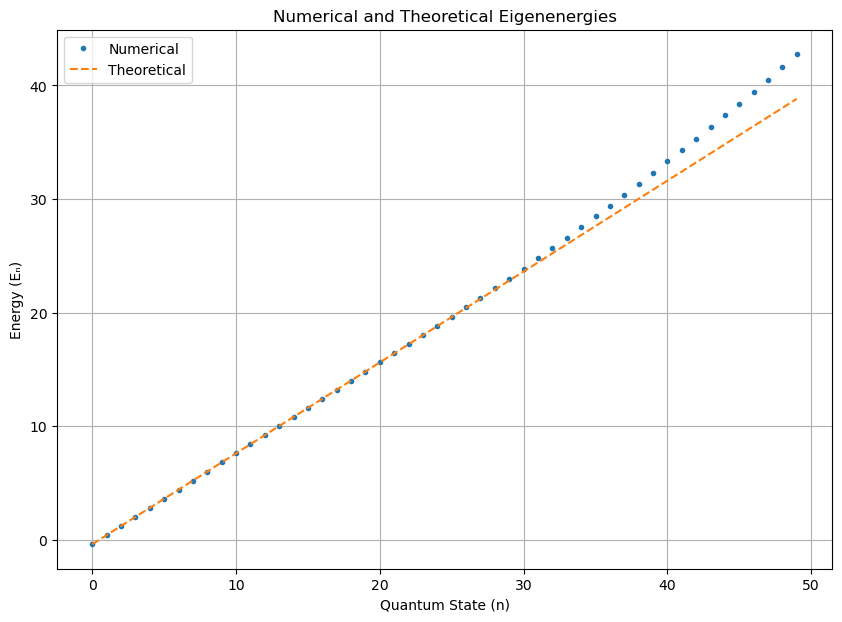

In [12]:
# Parameters
m = 1
hbar = 1
q = -1                 # electron charge
E_field = 1 / q       # E = q^(-1)
w = 0.8

N_points = 1000
x = np.linspace(-10, 10, N_points)
dx = x[1] - x[0]

# Effective potential
Vx = 0.5 * m * (w**2) * (x**2) + q * E_field * x

H = hamiltonian(x, Vx, m)
eigenvalues, eigenvectors = np.linalg.eigh(H)

# First 50 numerical eigenenergies
N_energy = 50
n = np.arange(N_energy)

numerical_E = eigenvalues[:N_energy]

# Theoretical eigenenergies
theoretical_E = hbar * w * (n + 0.5) - (q**2 * E_field**2) / (2 * m * w**2)

# Plot
plt.figure(figsize=(10, 7))

plt.plot(n, numerical_E, 'o', markersize=3, label="Numerical")
plt.plot(n, theoretical_E, '--', label="Theoretical")

plt.xlabel("Quantum State (n)")
plt.ylabel("Energy (Eₙ)")
plt.title("Numerical and Theoretical Eigenenergies")
plt.legend()
plt.grid()
plt.savefig('Figures/e6_figure2')
plt.show()

Total Integrated Probability: 1.000000


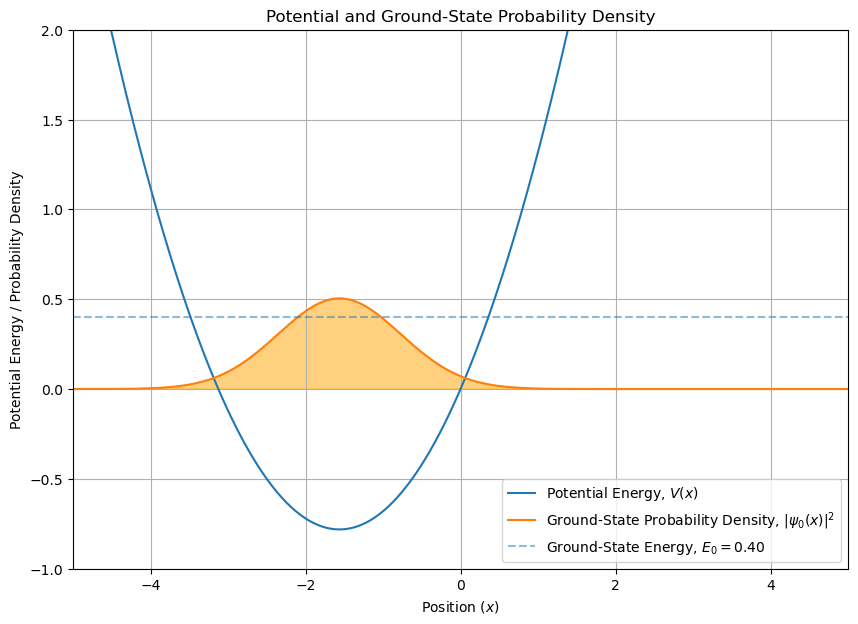

In [15]:
psi_raw = eigenvectors[:,0]
norm_sq = np.trapz(np.abs(psi_raw)**2, x)
psi_0 = psi_raw / np.sqrt(norm_sq) # Ground-state eigenfunction

prob_density = (np.abs(psi_0))**2 # Ground-state probability density 

total_prob = np.trapz(prob_density, x)
print(f"Total Integrated Probability: {total_prob:.6f}")

# Plot
plt.figure(figsize=(10, 7))

plt.plot(x, Vx, label="Potential Energy, $V(x)$")

plt.plot(x, prob_density, label="Ground-State Probability Density, $|\psi_0(x)|^2$")
plt.fill_between(x, prob_density, color='orange', alpha=0.5)

plt.axhline(E_0, linestyle="--", alpha=0.5,
            label=f"Ground-State Energy, $E_0 = {E_0:.2f}$")

plt.ylim(-1,2)
plt.xlim(-5,5)

plt.xlabel("Position ($x$)")
plt.ylabel("Potential Energy / Probability Density")
plt.title("Potential and Ground-State Probability Density")
plt.legend()
plt.grid()
plt.savefig('Figures/e6_figure3')
plt.show()

#### Problem 2 code summary

This code constructs the Hamiltonian for a harmonic oscillator in a uniform electric field and compares the first 50 numerical eigenenergies with their theoretical values. The ground-state eigenvector is then normalized using numerical integration so that its probability density can be plotted alongside the shifted potential, allowing the spatial distribution of the ground state to be examined.

---

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)